# IFNβ / IFNγ response in PBMCs (Dong et al. 2023)

**Questions**
1. Which cell types respond to IFNβ, IFNγ and the combination, and how strongly?
2. Is the combined response additive, or larger or smaller than the sum of the single responses?

**Focused test: MHC class II in monocytes.** Does IFNβ reduce IFNγ's effect on MHC-II in monocytes?

**Multiple testing.** Benjamini–Hochberg FDR correction across exploratory comparisons; the MHC-II test is the literature-motivated hypothesis, all other results (including CXCL9) are exploratory.

**Contents:** 1. Data · 2. Gene sets · 3. Which cell types respond? · 4. Focused test and per-gene results · 5. Is the combination additive?

Needs `data/dong_2023_raw.h5ad` (saved by `01_load_inspect.py`); section 2b downloads the Hallmark sets.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")  # harmless Jupyter progress-bar warning
import re
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

SEED = 0   # each section below re-seeds from this, so results don't depend on run order
FIG = Path("results/figures"); FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 200)

## 1. Load the data

`X` in this file holds only 773 scaled genes, so we use `adata.raw`: log-normalised expression of all 21,819 genes (already in the file).

In [2]:
adata = sc.read_h5ad("data/dong_2023_raw.h5ad")
ad = adata.raw.to_adata()                 # all genes, log-normalised
ad.obsm["X_umap"] = adata.obsm["X_umap"]  # keep the authors' UMAP
print(ad)
print(f"\nX (scaled): {adata.n_vars} genes | raw: {ad.n_vars} genes")
print("raw min / max:", float(ad.X.min()), "/", float(ad.X.max()))
rs = np.asarray(np.expm1(ad.X[:500].toarray() if hasattr(ad.X, "toarray") else ad.X[:500]).sum(1)).ravel()
print("expm1(raw) per-cell totals, median:", round(float(np.median(rs)), 1),
      "(roughly constant = log1p of normalised counts)")

AnnData object with n_obs × n_vars = 9209 × 21819
    obs: 'perturbation', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch', 'leiden', 'cell_type0528'
    uns: 'batch_colors', 'cell_type0528_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'perturbation_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'
    layers: None (.X)

X (scaled): 773 genes | raw: 21819 genes
raw min / max: 0.0 / 7.2369794845581055
expm1(raw) per-cell totals, median: 2856.0 (roughly constant = log1p of normalised counts)


In [3]:
# Is .raw normalised? After undoing the log, every cell should have the same total.
tot = np.asarray(ad.X.expm1().sum(1)).ravel()
print("expm1(raw) per-cell totals 5/50/95%:", np.percentile(tot, [5, 50, 95]).round(0))
if "total_counts" in ad.obs:
    print("original total_counts 5/50/95%:   ", np.percentile(ad.obs["total_counts"], [5, 50, 95]).round(0))
    print("correlation with original depth:  ", np.corrcoef(tot, ad.obs["total_counts"])[0, 1].round(3))
print("-> same total for every cell = normalised, then log1p. Differences between cells are biology, not sequencing depth.")

expm1(raw) per-cell totals 5/50/95%: [2856. 2856. 2856.]
original total_counts 5/50/95%:    [  881.  2030. 11198.]
correlation with original depth:   -0.003
-> same total for every cell = normalised, then log1p. Differences between cells are biology, not sequencing depth.


In [4]:
COND = {"No stimulation": "ctrl", "IFNb": "IFNb", "IFNg": "IFNg", "IFNb+ IFNg": "IFNb+IFNg"}
ORDER = list(COND.values())
ad.obs["condition"] = pd.Categorical(ad.obs["perturbation"].astype(str).map(COND), categories=ORDER)
ad.obs["cell_type"] = ad.obs["cell_type0528"].astype(str)
cond = ad.obs["condition"].astype(str).values
ct = ad.obs["cell_type"].values

tab = pd.crosstab(ad.obs["cell_type"], ad.obs["condition"])
TYPES = tab.index[(tab >= 20).all(axis=1)].tolist()
print(tab, "\n\nCell types with >= 20 cells in every condition (analysed):", TYPES)
# print("Donors/batches:", ad.obs["batch"].unique().tolist(), "-> one donor: cells are the only replicates")
for b in ad.obs["batch"].astype(str).unique():
    m = re.fullmatch(r"H(\d+)D(\d+)", b)
    label = f"donor {m.group(1)}, day {m.group(2)} of stimulation" if m else "unrecognised format"
    print(f"Batch {b}: {label}")
print("-> one donor: cells are the only replicates")

condition  ctrl  IFNb  IFNg  IFNb+IFNg
cell_type                             
B            96   130   126        133
CD4 T       569   814   377        701
CD8 T       309   421   325        356
Dendritic     4    10    16         17
Monocyte    602   608   473        504
NK          673   744   620        494
Plasma       15    32     7         33 

Cell types with >= 20 cells in every condition (analysed): ['B', 'CD4 T', 'CD8 T', 'Monocyte', 'NK']
Batch H3D2: donor 3, day 2 of stimulation
-> one donor: cells are the only replicates


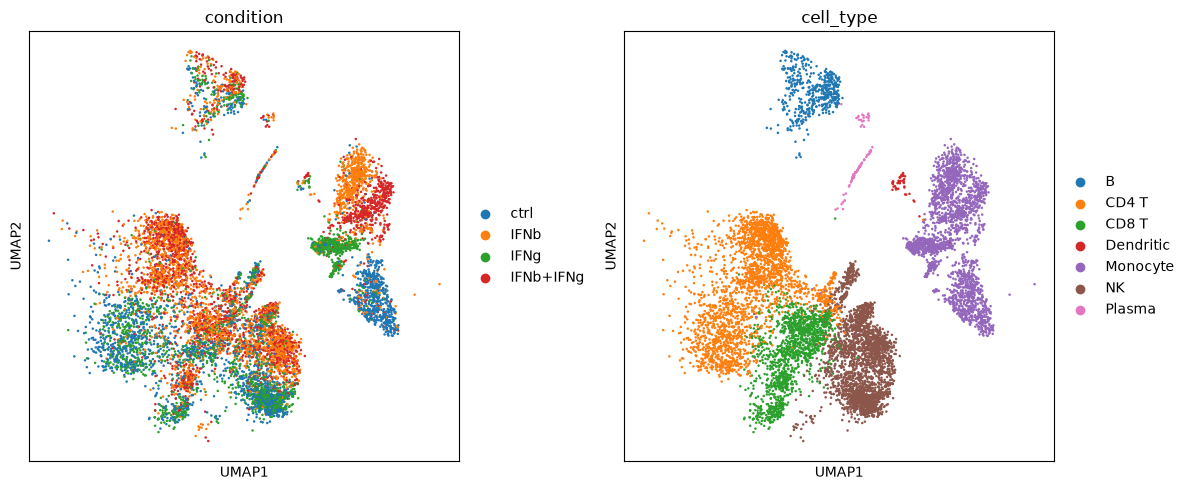

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.pl.umap(ad, color="condition", ax=axes[0], show=False)
sc.pl.umap(ad, color="cell_type", ax=axes[1], show=False)
plt.tight_layout(); plt.savefig(FIG / "nb_umap.png", dpi=150); plt.show()

## 2. Gene sets

### 2a. Gene-set scores

Gene sets were taken from established interferon-stimulated and antigen-presentation genes, not selected from this data. Score per cell = mean log expression of the set's genes.

| Set | Genes | What it measures |
|---|---|---|
| `type_I_ISG` | ISG15, MX1/2, IFIT1–3, IFI6, IFI44L, OAS1–3, RSAD2, HERC5 | response to IFNβ |
| `IFNG_specific` | CXCL9, CIITA, IDO1, GBP1/4/5 | response to IFNγ |
| `MHC_II` | HLA-DR/DP/DQ/DM genes, CD74 | antigen presentation to helper T cells |
| `MHC_I` | HLA-A/B/C/E, B2M | antigen presentation to killer T cells |

In [6]:
GENE_SETS = {
    "type_I_ISG":    ["ISG15", "MX1", "MX2", "IFIT1", "IFIT2", "IFIT3", "IFI6", "IFI44L",
                      "OAS1", "OAS2", "OAS3", "RSAD2", "HERC5"],
    "IFNG_specific": ["CXCL9", "CIITA", "IDO1", "GBP1", "GBP4", "GBP5"],
    "MHC_II":        ["HLA-DRA", "HLA-DRB1", "HLA-DPA1", "HLA-DPB1", "HLA-DQA1", "HLA-DQB1",
                      "HLA-DMA", "HLA-DMB", "CD74"],
    "MHC_I":         ["HLA-A", "HLA-B", "HLA-C", "HLA-E", "B2M"],
}
SETS = {}
for name, genes in GENE_SETS.items():
    present = [g for g in genes if g in ad.var_names]
    missing = sorted(set(genes) - set(present))
    print(f"{name:<14} {len(present)}/{len(genes)} genes present" + (f" (missing: {missing})" if missing else ""))
    if present:
        SETS[name] = present
        x = ad[:, present].X
        ad.obs[name] = np.asarray(x.mean(axis=1)).ravel()
print("\nCIITA present:", "CIITA" in ad.var_names)

type_I_ISG     13/13 genes present
IFNG_specific  6/6 genes present
MHC_II         9/9 genes present
MHC_I          5/5 genes present

CIITA present: True


**Mean score per cell type and condition.** Scores are mean log-normalised expression, so ranges differ between sets; each panel has its own colour scale. IFNβ raises the type I score in every cell type, while IFNγ acts mainly on monocytes and partly on B cells. In monocytes the combination gives a lower IFNγ-specific score than IFNγ alone, a first hint that IFNβ reduces IFNγ's effect, tested in section 4.

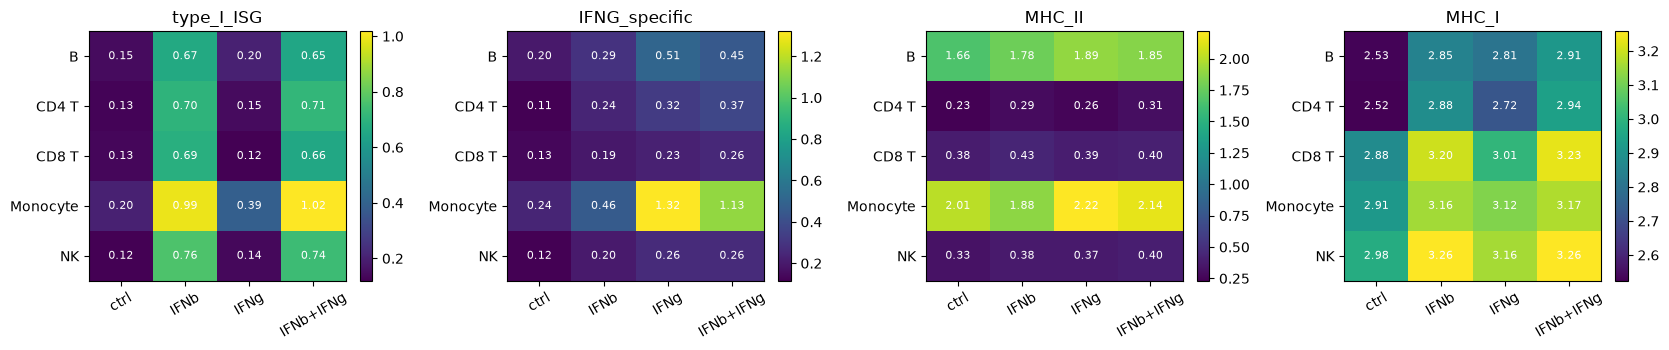

In [7]:
sub = ad.obs[ad.obs.cell_type.isin(TYPES)]
fig, axes = plt.subplots(1, len(SETS), figsize=(4.2 * len(SETS), 3.6))
for ax, name in zip(np.atleast_1d(axes), SETS):
    piv = sub.pivot_table(index="cell_type", columns="condition", values=name, observed=True)[ORDER]
    im = ax.imshow(piv.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(4), ORDER, rotation=30); ax.set_yticks(range(len(piv)), piv.index)
    for i in range(piv.shape[0]):
        for j in range(4):
            ax.text(j, i, f"{piv.values[i, j]:.2f}", ha="center", va="center", color="w", fontsize=8)
    ax.set_title(name); plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.savefig(FIG / "nb_set_scores.png", dpi=150); plt.show()

### 2b. Check against MSigDB Hallmark

How many of our genes are in the Hallmark interferon-α and interferon-γ response sets (Liberzon et al. 2015)?

In [8]:
import decoupler as dc

hm = dc.op.hallmark(organism="human")                       # downloads once
alpha_src = [s for s in hm.source.unique() if "INTERFERON_ALPHA" in s.upper()][0]
gamma_src = [s for s in hm.source.unique() if "INTERFERON_GAMMA" in s.upper()][0]
alpha = set(hm[hm.source == alpha_src].target)
gamma = set(hm[hm.source == gamma_src].target)

for mine, ref, src in [("type_I_ISG", alpha, alpha_src), ("IFNG_specific", gamma, gamma_src)]:
    print(f"{mine}: {sum(g in ref for g in SETS[mine])}/{len(SETS[mine])} genes in {src}")

print()
for name in ["type_I_ISG", "IFNG_specific"]:
    for g in SETS[name]:
        where = ", ".join(x for x, s in [("alpha", alpha), ("gamma", gamma)] if g in s) or "neither"
        print(f"{name:<14} {g:<8} -> Hallmark {where}")

type_I_ISG: 7/13 genes in INTERFERON_ALPHA_RESPONSE
IFNG_specific: 4/6 genes in INTERFERON_GAMMA_RESPONSE

type_I_ISG     ISG15    -> Hallmark alpha, gamma
type_I_ISG     MX1      -> Hallmark alpha, gamma
type_I_ISG     MX2      -> Hallmark gamma
type_I_ISG     IFIT1    -> Hallmark gamma
type_I_ISG     IFIT2    -> Hallmark alpha, gamma
type_I_ISG     IFIT3    -> Hallmark alpha, gamma
type_I_ISG     IFI6     -> Hallmark neither
type_I_ISG     IFI44L   -> Hallmark alpha, gamma
type_I_ISG     OAS1     -> Hallmark alpha
type_I_ISG     OAS2     -> Hallmark gamma
type_I_ISG     OAS3     -> Hallmark gamma
type_I_ISG     RSAD2    -> Hallmark alpha, gamma
type_I_ISG     HERC5    -> Hallmark neither
IFNG_specific  CXCL9    -> Hallmark gamma
IFNG_specific  CIITA    -> Hallmark gamma
IFNG_specific  IDO1     -> Hallmark gamma
IFNG_specific  GBP1     -> Hallmark neither
IFNG_specific  GBP4     -> Hallmark alpha, gamma
IFNG_specific  GBP5     -> Hallmark neither


**Reading.** 11 of 13 type I genes are in a Hallmark interferon set; IFI6 and HERC5 are not, but are documented type I interferon-induced genes (Schoggins et al. 2011; Wong et al. 2006). CXCL9, CIITA and IDO1 are in the γ set only, supporting them as IFNγ-specific. GBP1 and GBP5 are in neither but are interferon-induced GTPases (Tretina et al. 2019); in this data IFNβ also raises them, so they are IFNγ-dominant rather than strictly specific.

### 2c. Where are these genes active? (UMAP)

UMAP layout from the authors; colours show expression (yellow = high), each panel on its own scale. One marker per gene set (ISG15, CXCL9, HLA-DRA, plus CIITA as a detection check) is shown alongside the set scores. Expected: ISG15 high in IFNβ and combo cells of all cell types; CXCL9 high mainly in IFNγ monocytes; HLA-DRA high in monocytes and B cells; CIITA sparse.

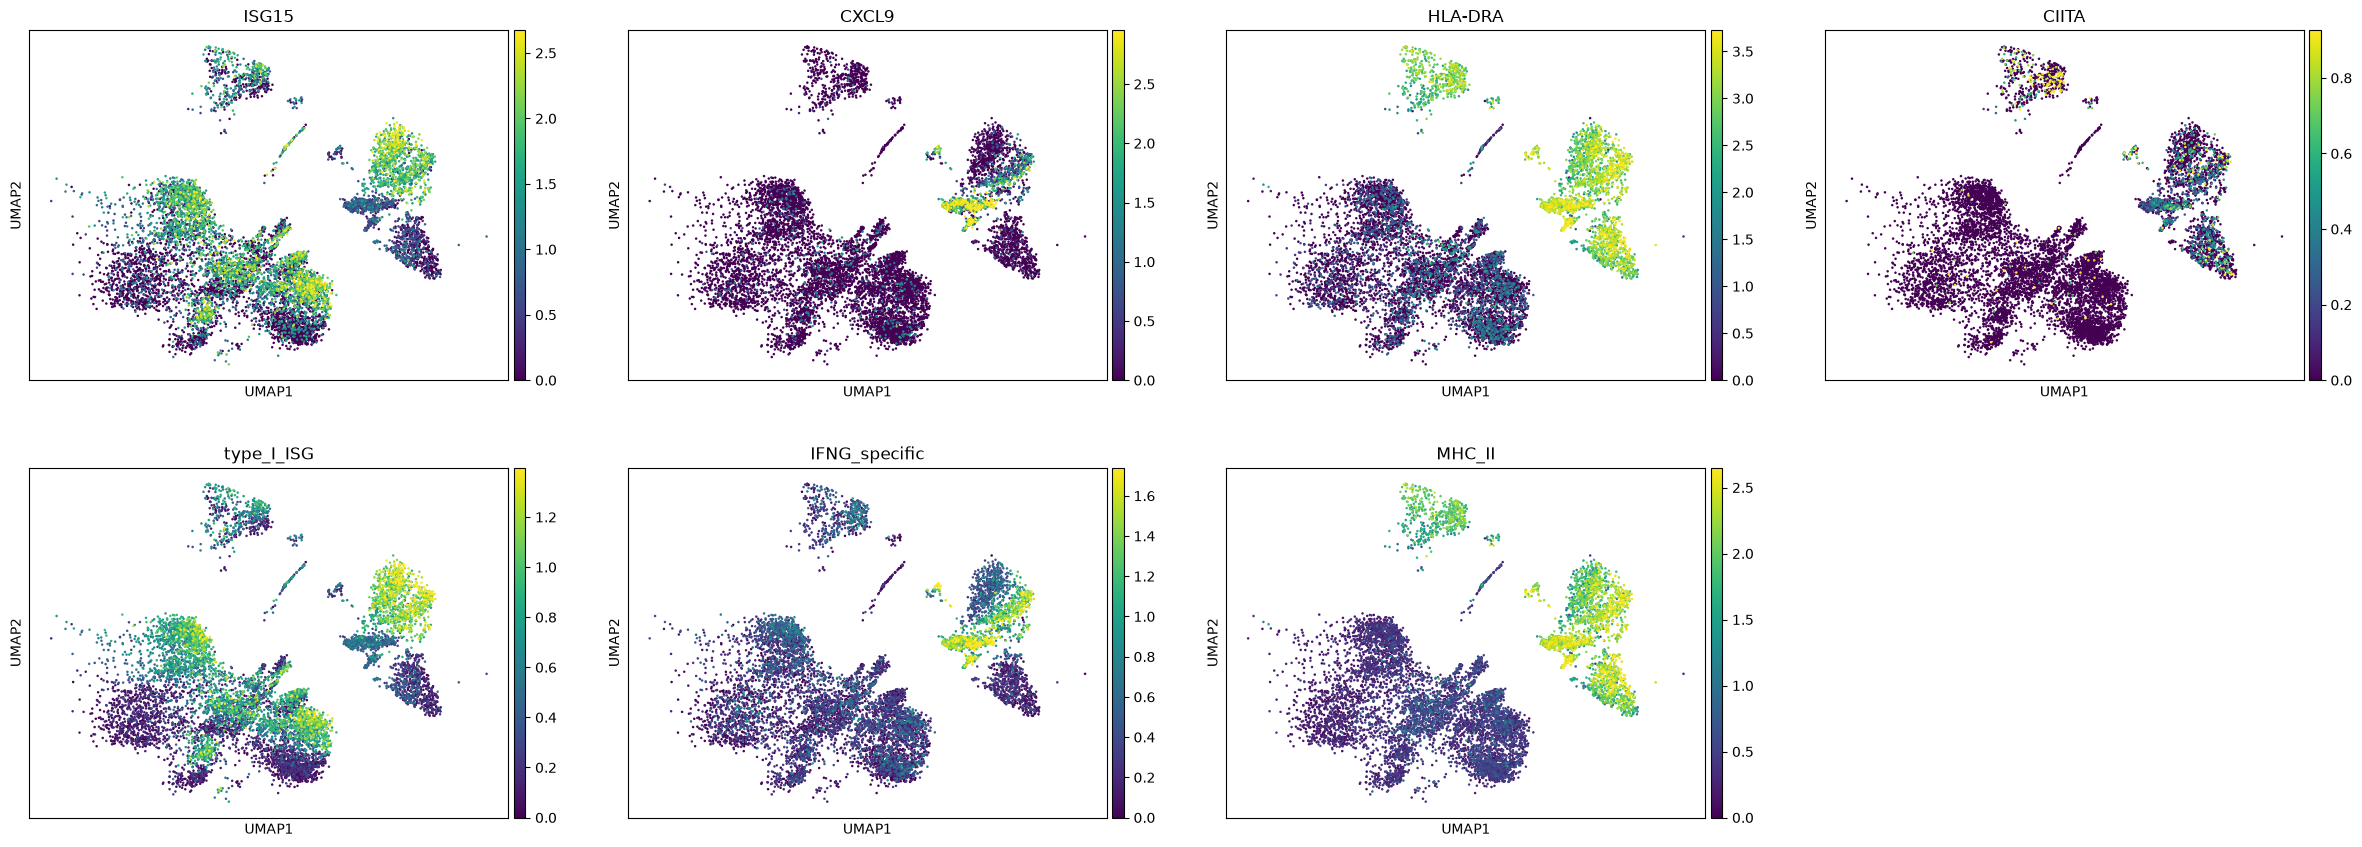

In [9]:
show_these = [g for g in ["ISG15", "CXCL9", "HLA-DRA", "CIITA", "type_I_ISG", "IFNG_specific", "MHC_II"]
              if g in ad.var_names or g in ad.obs]
sc.pl.umap(ad, color=show_these, ncols=4, cmap="viridis", vmax="p99", show=False)
plt.savefig(FIG / "nb_umap_genes.png", dpi=150, bbox_inches="tight"); plt.show()

**Dendritic cells.** Dendritic cells rise from 4 (ctrl) to 10–17 (stimulated). If IFNγ made monocytes look like dendritic cells, they would be relabelled and leave the monocyte group. On the UMAP the dendritic cells (circled) form their own small cluster, separate from the monocyte clusters. A formal check (repeating the monocyte test with dendritic cells pooled in) is listed as future work.

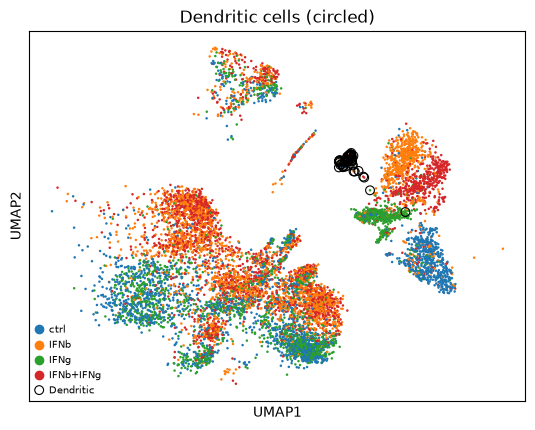

In [10]:
m = ad.obs["cell_type"] == "Dendritic"
ax = sc.pl.umap(ad, color="condition", show=False, title="Dendritic cells (circled)")
ax.scatter(*ad.obsm["X_umap"][m.values].T, s=40, facecolors="none", edgecolors="k", lw=0.8, label="Dendritic")
ax.legend(loc="lower left", fontsize=7)
plt.savefig(FIG / "nb_umap_dendritic.png", dpi=150, bbox_inches="tight"); plt.show()

## 3. Which cell types respond?

Two readouts per cell type and stimulus, both at **equal cell numbers** so differences in cell-type abundance do not bias the ranking. Features: the authors' 773 highly variable genes.

**a) Classifier AUC** (approach of Augur; Skinnider et al. 2021). Logistic regression distinguishing 20 stimulated from 20 control cells, 3-fold cross-validation, 30 repeats. 0.5 = no response, 1 = fully separable. **ctrl vs ctrl** (two random halves of control cells) is a control-vs-control check and should be ≈ 0.5.

**b) Signal-to-noise ratio.** Distance between the average stimulated and average control profile, divided by the distance between two random halves of control cells (40 cells per group, 20 repeats). 1 = no bigger than noise. Unlike the AUC it has no ceiling, so it can rank strong responses.

In [11]:
rng = np.random.default_rng(SEED)
feat = [g for g in adata.var_names if g in ad.var_names]
Xf = ad[:, feat].X
Xf = Xf.toarray() if hasattr(Xf, "toarray") else np.asarray(Xf)
N, REPEATS = 20, 30
STIMS = ["IFNb", "IFNg", "IFNb+IFNg"]


def auc_once(a, b):
    Xs, y = np.vstack([Xf[a], Xf[b]]), np.r_[np.zeros(len(a)), np.ones(len(b))]
    cv = StratifiedKFold(3, shuffle=True, random_state=int(rng.integers(1e9)))
    return cross_val_score(LogisticRegression(max_iter=1000), Xs, y, cv=cv, scoring="roc_auc").mean()


rows = []
for t in TYPES:
    ic = np.where((ct == t) & (cond == "ctrl"))[0]
    # noise check: two disjoint halves of the control cells
    aucs = []
    for _ in range(REPEATS):
        p = rng.permutation(ic)
        aucs.append(auc_once(p[:N], p[N:2 * N]))
    rows.append({"cell_type": t, "stim": "ctrl vs ctrl", "auc": np.mean(aucs), "sd": np.std(aucs)})
    for s in STIMS:
        is_ = np.where((ct == t) & (cond == s))[0]
        aucs = [auc_once(rng.choice(ic, N, replace=False), rng.choice(is_, N, replace=False))
                for _ in range(REPEATS)]
        rows.append({"cell_type": t, "stim": s, "auc": np.mean(aucs), "sd": np.std(aucs)})
auc = pd.DataFrame(rows)
auc_wide = auc.pivot(index="cell_type", columns="stim", values="auc")[["ctrl vs ctrl"] + STIMS]
auc_wide.round(3)

stim,ctrl vs ctrl,IFNb,IFNg,IFNb+IFNg
cell_type,,,,
B,0.519,0.981,0.832,0.983
CD4 T,0.492,0.962,0.775,0.970
CD8 T,0.526,0.939,0.574,0.945
Monocyte,0.487,0.956,0.951,0.974
NK,0.550,0.944,0.609,0.957


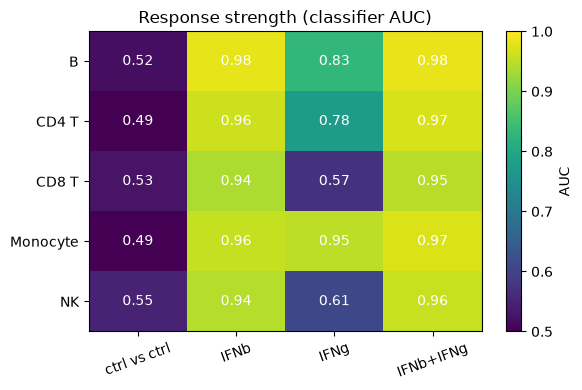

In [12]:
fig, ax = plt.subplots(figsize=(6, 0.5 * len(auc_wide) + 1.5))
im = ax.imshow(auc_wide.values, aspect="auto", cmap="viridis", vmin=0.5, vmax=1)
ax.set_xticks(range(auc_wide.shape[1]), auc_wide.columns, rotation=20)
ax.set_yticks(range(len(auc_wide)), auc_wide.index)
for i in range(auc_wide.shape[0]):
    for j in range(auc_wide.shape[1]):
        ax.text(j, i, f"{auc_wide.values[i, j]:.2f}", ha="center", va="center", color="w")
plt.colorbar(im, label="AUC"); ax.set_title("Response strength (classifier AUC)")
plt.tight_layout(); plt.savefig(FIG / "nb_response_auc.png", dpi=150); plt.show()

IFNβ AUCs are all near 1 (0.94–0.98), so the AUC cannot rank the IFNβ responses; the signal-to-noise ratio below does.

In [13]:
rng = np.random.default_rng(SEED + 1)


def magnitude(t, s, n=40, reps=20):
    ic = np.where((ct == t) & (cond == "ctrl"))[0]
    is_ = np.where((ct == t) & (cond == s))[0]
    n = min(n, len(ic) // 2, len(is_))
    sig, noise = [], []
    for _ in range(reps):
        p = rng.permutation(ic)
        c1, c2 = p[:n], p[n:2 * n]
        st = rng.choice(is_, n, replace=False)
        sig.append(np.linalg.norm(Xf[st].mean(0) - Xf[c1].mean(0)))
        noise.append(np.linalg.norm(Xf[c2].mean(0) - Xf[c1].mean(0)))
    return np.mean(sig) / np.mean(noise)


mag = pd.DataFrame({s: {t: magnitude(t, s) for t in TYPES} for s in STIMS})[STIMS]
print("Response size / noise floor (1 = no bigger than noise):")
mag.round(2)

Response size / noise floor (1 = no bigger than noise):


,IFNb,IFNg,IFNb+IFNg
B,2.25,1.46,2.29
CD4 T,2.64,1.32,2.97
CD8 T,2.21,1.14,2.28
Monocyte,3.78,3.63,4.57
NK,2.16,1.14,2.16


## 4. Does IFNβ reduces IFNγ-driven MHC-II in monocytes?

**Data.** Gene-set scores per cell (section 2). The focused test uses MHC-II in monocytes; other sets and cell types are exploratory.

**Comparisons** (from the mean scores of ctrl, IFNβ, IFNγ and combo):
- **IFNβ effect** = IFNβ − ctrl
- **IFNγ effect** = IFNγ − ctrl
- **combo − IFNγ**: is the combination lower than IFNγ alone?
- **Interaction** = (combo − IFNβ) − (IFNγ − ctrl): does IFNγ's effect change when IFNβ is present? Below 0 = dampening; ≈ 0 = the effects add. This is the focused test.

**Why not just compare combo with IFNγ?** IFNβ lowers MHC-II on its own, so the combination can be lower than IFNγ alone without any dampening.

**Statistics.** Two-way ANOVA (`score ~ IFNβ × IFNγ`) on cells, with robust (HC3) 95% CIs. "Up/down" = CI excludes 0. Exploratory comparisons use Benjamini–Hochberg q-values.

In [ ]:
CONTRASTS = ["IFNb_effect", "IFNg_effect", "combo_minus_IFNg", "interaction"]
# Each contrast as weights on the model coefficients (Intercept = ctrl mean)
WEIGHTS = {"IFNb_effect":      {"IFNb": 1},
           "IFNg_effect":      {"IFNg": 1},
           "combo_minus_IFNg": {"IFNb": 1, "IFNb:IFNg": 1},
           "interaction":      {"IFNb:IFNg": 1},
           "combo_effect":     {"IFNb": 1, "IFNg": 1, "IFNb:IFNg": 1},   # combo - ctrl, for section 5
           "IFNg_with_IFNb":   {"IFNg": 1, "IFNb:IFNg": 1}}   # combo - IFNb = IFNγ's effect with IFNβ (section 4b)


def lm_contrasts(v, c):
    """Two-way linear model on cells (= two-way ANOVA with interaction): y ~ IFNb * IFNg,
    OLS with heteroskedasticity-robust (HC3) standard errors.
    Returns {contrast: (estimate, ci_low, ci_high, p_value)}."""
    d = pd.DataFrame({"y": np.asarray(v, float),
                      "IFNb": np.isin(c, ["IFNb", "IFNb+IFNg"]).astype(int),
                      "IFNg": np.isin(c, ["IFNg", "IFNb+IFNg"]).astype(int)})
    fit = smf.ols("y ~ IFNb * IFNg", data=d).fit(cov_type="HC3")
    out = {}
    for k, w in WEIGHTS.items():
        t = fit.t_test(np.array([[w.get(n, 0) for n in fit.params.index]], float))
        lo, hi = np.asarray(t.conf_int()).ravel()
        out[k] = (float(np.ravel(t.effect)[0]), float(lo), float(hi), float(np.ravel(t.pvalue)[0]))
    return out


def add_calls(r):
    """Call from the 95% CI; q = Benjamini-Hochberg across the 4 main contrasts of the whole table."""
    r["call"] = np.select([r.hi < 0, r.lo > 0], ["down", "up"], "n.s.")
    main = r.contrast.isin(CONTRASTS)
    r["q"] = np.nan
    r.loc[main, "q"] = multipletests(r.loc[main, "p"], method="fdr_bh")[1]
    fq = lambda q: "" if np.isnan(q) else ("q<0.001" if q < 0.001 else f"q={q:.3f}")
    r["txt"] = r.apply(lambda x: f"{x.est:+.3f} [{x.lo:+.3f}, {x.hi:+.3f}] {x.call} {fq(x.q)}", axis=1)
    return r


def contrast_table(groups):
    rows = []
    for gname, m in groups.items():
        for name in SETS:
            for k, (est, lo, hi, pv) in lm_contrasts(ad.obs[name].values[m], cond[m]).items():
                rows.append({"cell_type": gname, "set": name, "contrast": k,
                             "est": est, "lo": lo, "hi": hi, "p": pv})
    return add_calls(pd.DataFrame(rows))


def verdict(r, group, s="MHC_II"):
    """Plain-language call from three contrasts. 'Dampening' = interaction opposite to IFNg's own effect."""
    d = r[(r.cell_type == group) & (r.set == s)].set_index("contrast")["call"]
    g, cm, it = d["IFNg_effect"], d["combo_minus_IFNg"], d["interaction"]
    if g == "n.s.":
        return f"IFNg has no clear effect on {s} here, so dampening cannot be judged"
    opp = "down" if g == "up" else "up"
    same_w, opp_w = ("raises", "lowers") if g == "up" else ("lowers", "raises")
    if it == opp:
        return ("IFNb dampens IFNg's effect" if cm == opp
                else f"IFNg's effect is smaller with IFNb, but IFNb {same_w} {s} on its own")
    if it == g:
        return "IFNg's effect is LARGER with IFNb (super-additive)"
    if cm == opp:
        return f"IFNb {opp_w} {s} on its own; no evidence that it dampens IFNg's effect"
    return "no clear dampening (interaction CI includes 0)"


res = contrast_table({t: ct == t for t in TYPES})
res.to_csv("results/nb_set_contrasts.csv", index=False)

MONO = [t for t in TYPES if "mono" in t.lower()]
print("Monocyte group(s):", MONO)
for t in MONO:
    print(f"FOCUSED TEST   ({t}, MHC-II):        {verdict(res, t)}")
    if "IFNG_specific" in SETS:
        print(f"Secondary/expl ({t}, IFNg-specific): {verdict(res, t, 'IFNG_specific')}")
res[res.cell_type.isin(MONO)].pivot(index="set", columns="contrast", values="txt")[CONTRASTS]

Monocyte group(s): ['Monocyte']
FOCUSED TEST   (Monocyte, MHC-II):        IFNb lowers MHC_II on its own; no evidence that it dampens IFNg's effect
Secondary/expl (Monocyte, IFNg-specific): IFNb dampens IFNg's effect


contrast,IFNb_effect,IFNg_effect,combo_minus_IFNg,interaction
set,,,,
IFNG_specific,"+0.219 [+0.184, +0.255] up q<0.001","+1.081 [+1.036, +1.126] up q<0.001","-0.193 [-0.244, -0.143] down q<0.001","-0.413 [-0.474, -0.351] down q<0.001"
MHC_I,"+0.241 [+0.212, +0.270] up q<0.001","+0.204 [+0.177, +0.232] up q<0.001","+0.050 [+0.022, +0.078] up q<0.001","-0.191 [-0.231, -0.151] down q<0.001"
MHC_II,"-0.132 [-0.181, -0.083] down q<0.001","+0.205 [+0.156, +0.254] up q<0.001","-0.075 [-0.124, -0.027] down q=0.003","+0.057 [-0.012, +0.125] n.s. q=0.120"
type_I_ISG,"+0.789 [+0.758, +0.819] up q<0.001","+0.190 [+0.167, +0.213] up q<0.001","+0.625 [+0.596, +0.654] up q<0.001","-0.164 [-0.206, -0.122] down q<0.001"


**Reading.** Each entry: estimate [95% CI], call, q-value.
- **MHC-II (focused test):** IFNγ raises MHC-II (+0.21) and IFNβ lowers it on its own (−0.13). The combination is lower than IFNγ alone (−0.08), but the interaction is ≈ 0 (+0.06, CI includes 0): **no dampening**, the effects add.
- **IFNγ-specific genes:** interaction −0.41: **IFNβ dampens IFNγ's effect**, even though IFNβ raises these genes slightly on its own.
- **Type I ISGs and MHC-I:** interactions −0.16 and −0.19, but the combination is at least as high as the stronger single interferon: **sub-additive**, consistent with a ceiling.

### 4b. Per gene in monocytes

The same test for each gene in the MHC-II, IFNγ-specific and MHC-I sets.
- **Middle panel:** circle = IFNγ's effect alone (IFNγ − ctrl); square = IFNγ's effect with IFNβ (combo − IFNβ). A long grey line means IFNβ weakens IFNγ's effect on that gene.
- **Right panel:** is the gene actually lower with both interferons than with IFNγ alone? Below 0 together with a long grey line = IFNβ blocks IFNγ (e.g. CXCL9). Around 0 = the gene was already near its maximum (e.g. GBP5).
- `it_q` = Benjamini–Hochberg-adjusted p for the interaction across these genes.

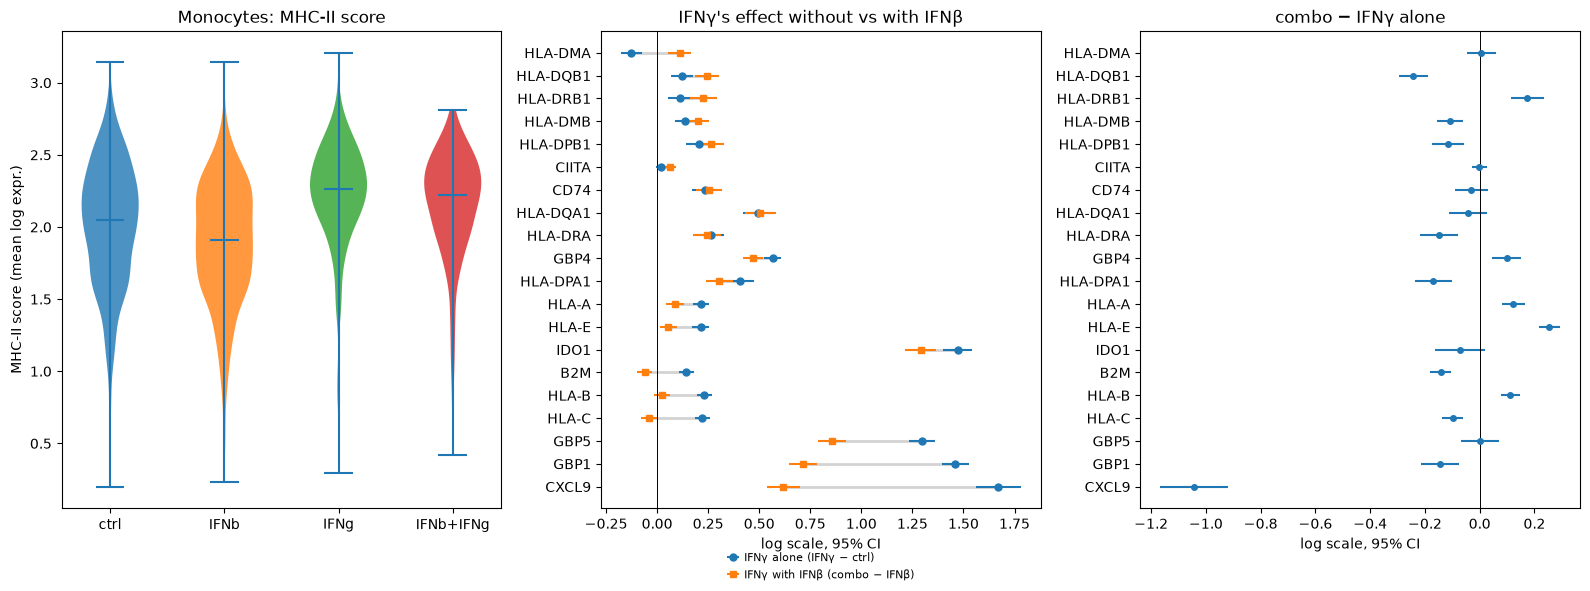

,gene,IFNb_effect,IFNg_effect,w,combo_minus_IFNg,interaction,it_q
9,CXCL9,0.011,1.672,0.617,-1.044,-1.054,0.000
12,GBP1,0.604,1.460,0.712,-0.145,-0.748,0.000
14,GBP5,0.443,1.296,0.855,0.002,-0.440,0.000
17,HLA-C,0.162,0.222,-0.038,-0.098,-0.260,0.000
16,HLA-B,0.321,0.232,0.023,0.112,-0.209,0.000
19,B2M,0.062,0.143,-0.062,-0.142,-0.204,0.000
11,IDO1,0.110,1.471,1.290,-0.072,-0.181,0.001
18,HLA-E,0.412,0.212,0.055,0.255,-0.158,0.000
15,HLA-A,0.248,0.213,0.088,0.123,-0.125,0.000
2,HLA-DPA1,-0.067,0.406,0.304,-0.169,-0.102,0.045


In [15]:
mono = ad[ad.obs.cell_type.isin(MONO)].copy()
genes = list(dict.fromkeys(g for g in GENE_SETS["MHC_II"] + GENE_SETS["IFNG_specific"] + GENE_SETS["MHC_I"]
                            if g in mono.var_names))
mc = mono.obs["condition"].astype(str).values


rows = []
for g in genes:
    x = mono[:, g].X
    x = np.asarray(x.toarray() if hasattr(x, "toarray") else x).ravel()
    r = lm_contrasts(x, mc)
    rows.append({"gene": g, "IFNb_effect": r["IFNb_effect"][0], "IFNg_effect": r["IFNg_effect"][0],
                 "combo_minus_IFNg": r["combo_minus_IFNg"][0], "cm_lo": r["combo_minus_IFNg"][1],
                 "cm_hi": r["combo_minus_IFNg"][2],
                 "interaction": r["interaction"][0], "it_lo": r["interaction"][1], "it_hi": r["interaction"][2],
                 "it_p": r["interaction"][3],
                 "w": r["IFNg_with_IFNb"][0], "w_lo": r["IFNg_with_IFNb"][1], "w_hi": r["IFNg_with_IFNb"][2],
                 "g_lo": r["IFNg_effect"][1], "g_hi": r["IFNg_effect"][2]})
pg = pd.DataFrame(rows)
pg["it_q"] = multipletests(pg["it_p"], method="fdr_bh")[1]   # BH across the genes shown
pg = pg.sort_values("interaction")

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
y = np.arange(len(pg))

# left: MHC-II score per condition
pal = dict(zip(ad.obs["condition"].cat.categories, ad.uns.get("condition_colors", [f"C{i}" for i in range(4)])))
parts = axes[0].violinplot([mono.obs.loc[mc == k, "MHC_II"].values for k in ORDER], showmedians=True)
for body, k in zip(parts["bodies"], ORDER):
    body.set_facecolor(pal[k]); body.set_alpha(0.8)
axes[0].set_xticks(range(1, 5), ORDER); axes[0].set_ylabel("MHC-II score (mean log expr.)")
axes[0].set_title("Monocytes: MHC-II score")

# middle: IFNγ's effect without vs with IFNβ (the gap is the interaction)
ax = axes[1]
ax.hlines(y, pg["IFNg_effect"], pg["w"], color="lightgrey", lw=2)
ax.errorbar(pg["IFNg_effect"], y, xerr=[pg["IFNg_effect"] - pg["g_lo"], pg["g_hi"] - pg["IFNg_effect"]],
            fmt="o", ms=5, label="IFNγ alone (IFNγ − ctrl)")
ax.errorbar(pg["w"], y, xerr=[pg["w"] - pg["w_lo"], pg["w_hi"] - pg["w"]],
            fmt="s", ms=5, label="IFNγ with IFNβ (combo − IFNβ)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=1, fontsize=8)
ax.set_title("IFNγ's effect without vs with IFNβ")

# right: combo − IFNγ alone (is the gene actually lower with both?)
ax = axes[2]
ax.errorbar(pg["combo_minus_IFNg"], y, xerr=[pg["combo_minus_IFNg"] - pg["cm_lo"], pg["cm_hi"] - pg["combo_minus_IFNg"]],
            fmt="o", ms=4)
ax.set_title("combo − IFNγ alone")

for ax in axes[1:]:
    ax.axvline(0, c="k", lw=0.7); ax.set_yticks(y, pg.gene); ax.set_xlabel("log scale, 95% CI")
plt.tight_layout(); plt.savefig(FIG / "nb_monocyte_mhc.png", dpi=150); plt.show()
pg[["gene", "IFNb_effect", "IFNg_effect", "w", "combo_minus_IFNg", "interaction", "it_q"]].round(3)


## 5. Is the combination additive?

Observed combination effect vs the sum of the two single effects, per cell type. The error bar is the 95% CI of the observed combination; the table below each plot gives the interaction (0 = additive).

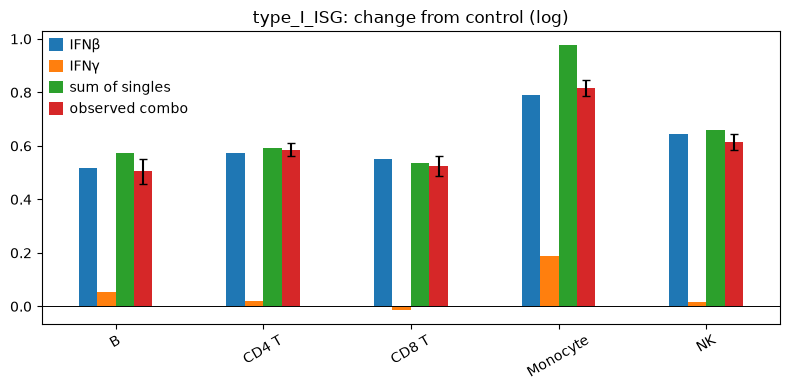

,interaction [95% CI]
cell_type,
B,"-0.068 [-0.135, -0.001] down q=0.060"
CD4 T,"-0.007 [-0.041, +0.028] n.s. q=0.703"
CD8 T,"-0.012 [-0.061, +0.038] n.s. q=0.660"
Monocyte,"-0.164 [-0.206, -0.122] down q<0.001"
NK,"-0.046 [-0.086, -0.006] down q=0.029"


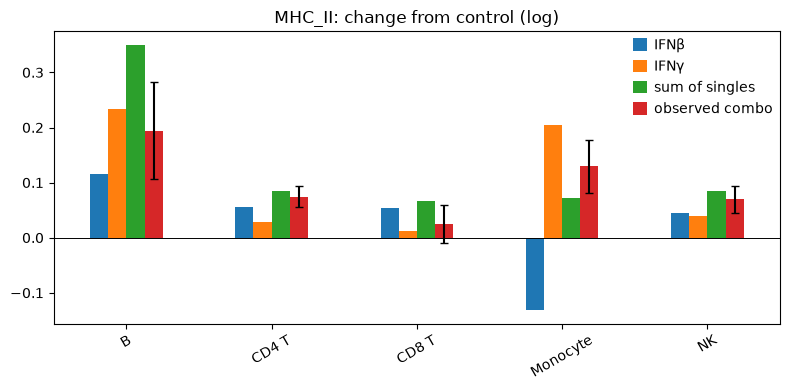

,interaction [95% CI]
cell_type,
B,"-0.156 [-0.280, -0.032] down q=0.018"
CD4 T,"-0.010 [-0.039, +0.018] n.s. q=0.506"
CD8 T,"-0.042 [-0.088, +0.005] n.s. q=0.096"
Monocyte,"+0.057 [-0.012, +0.125] n.s. q=0.120"
NK,"-0.014 [-0.047, +0.018] n.s. q=0.422"


In [16]:
for name in ["type_I_ISG", "MHC_II"]:
    if name not in SETS:
        continue
    d = res[res.set == name].pivot(index="cell_type", columns="contrast", values="est").loc[TYPES]
    combo = d["combo_effect"]                                   # = combo - ctrl
    ce = res[(res.set == name) & (res.contrast == "combo_effect")].set_index("cell_type")
    ci = {t: (ce.loc[t, "lo"], ce.loc[t, "hi"]) for t in TYPES}
    bars = pd.DataFrame({"IFNβ": d["IFNb_effect"], "IFNγ": d["IFNg_effect"],
                         "sum of singles": d["IFNb_effect"] + d["IFNg_effect"], "observed combo": combo})
    fig, ax = plt.subplots(figsize=(8, 4))
    bars.plot.bar(ax=ax, rot=30)
    err = np.array([[combo[t] - ci[t][0], ci[t][1] - combo[t]] for t in TYPES]).T
    ax.errorbar(np.arange(len(TYPES)) + 0.1875, combo.values, yerr=err, fmt="none", ecolor="k", capsize=3)
    ax.axhline(0, c="k", lw=0.7); ax.set_title(f"{name}: change from control (log)"); ax.set_xlabel("")
    plt.tight_layout(); plt.savefig(FIG / f"nb_additivity_{name}.png", dpi=150); plt.show()
    display(res[(res.set == name) & (res.contrast == "interaction")][["cell_type", "txt"]]
            .rename(columns={"txt": "interaction [95% CI]"}).set_index("cell_type"))